# Exploratory Data Analysis (EDA)

## Objective

The objective of this notebook is to explore the Student Placement Prediction Dataset, identify patterns, understand relationships between variables, and discover insights that influence student placement and salary prediction.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Display all columns
pd.set_option("display.max_columns", None)

print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [2]:
placement_df = pd.read_csv(r"C:\Users\rohit\Documents\CareerInsight AI Student Placement Prediction & Analytics Platform\data\raw\Indian_Student_Placement_Dataset_2025.csv")

In [3]:
placement_df.head()

,student_id,gender,age,degree,branch,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,aptitude_score,projects,placed,company_type,package_lpa
0,1,Male,20,BE,Mechanical,8.40,2,2,2,1,3,69,0,0,NaN,0.0
1,2,Female,20,BTech,Electrical,8.60,2,0,5,1,9,81,4,0,NaN,0.0
2,3,Male,22,BCA,Electrical,6.62,3,0,1,1,7,50,1,0,NaN,0.0
3,4,Male,24,BCA,DS,8.01,0,0,4,4,7,47,4,0,NaN,0.0
4,5,Male,24,BCA,Electrical,9.12,2,1,2,4,4,77,4,0,NaN,0.0


In [4]:
#How many students got placed?
placement_df["placed"].value_counts()

placed
0    8348
1    3652
Name: count, dtype: int64

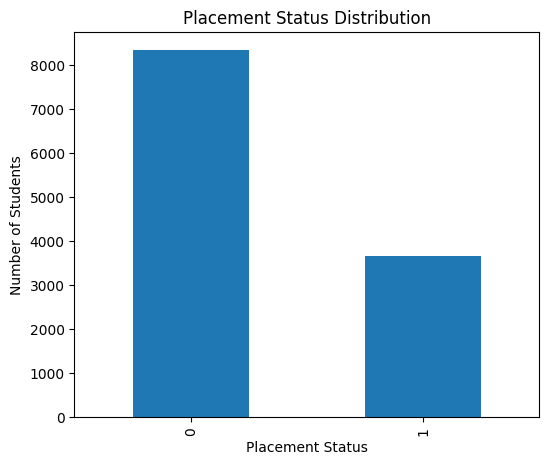

In [5]:
placement_df["placed"].value_counts().plot(
    kind="bar",
    figsize=(6,5),
    title="Placement Status Distribution"
)

plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

### Observation
- The dataset contains students who were placed and not placed.
- The classes are nearly balanced (approximately 54% placed and 46% not placed).
- A balanced dataset is beneficial for machine learning because it reduces prediction bias.

In [6]:
#Does CGPA affect placement?
cgpa_placement = placement_df.groupby("placed")["cgpa"].mean()
cgpa_placement

placed
0    7.427245
1    8.143771
Name: cgpa, dtype: float64

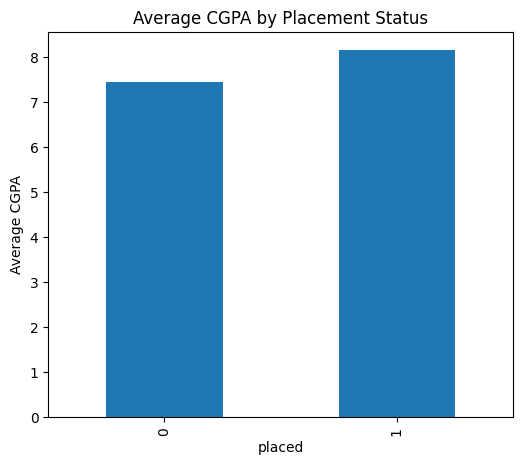

In [7]:
cgpa_placement.plot(
    kind="bar",
    figsize=(6,5),
    title="Average CGPA by Placement Status"
)

plt.ylabel("Average CGPA")
plt.show()

### Observation
- Students who are placed generally have a higher average CGPA than students who are not placed.
- This indicates that academic performance is an important factor influencing placement.

In [8]:
#Which Branch has the highest placement?
branch = placement_df.groupby("branch")["placed"].value_counts().unstack()
branch

placed,0,1
branch,,
AI,1406,610
CS,1369,581
DS,1351,640
Electrical,1387,594
IT,1383,572
Mechanical,1452,655


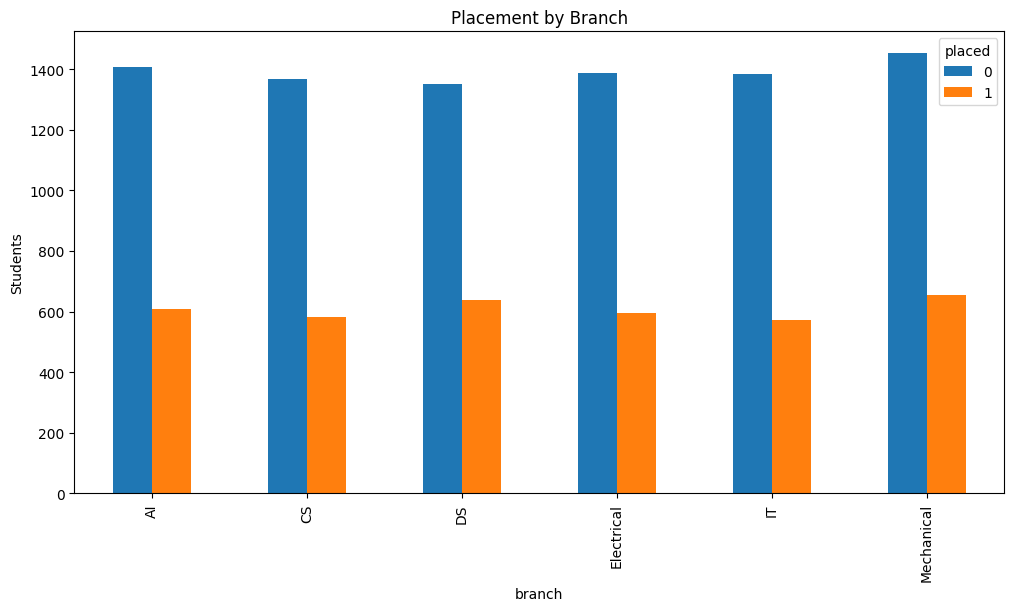

In [9]:
branch.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Placement by Branch")
plt.ylabel("Students")
plt.show()

### Observation
Different branches show different placement trends.
Some branches achieve higher placement percentages than others, suggesting branch-specific demand in the job market.

In [10]:
# 4.Do internships improve placement?
internship = placement_df.groupby("placed")["internships"].mean()
internship

placed
0    1.488860
1    1.529299
Name: internships, dtype: float64

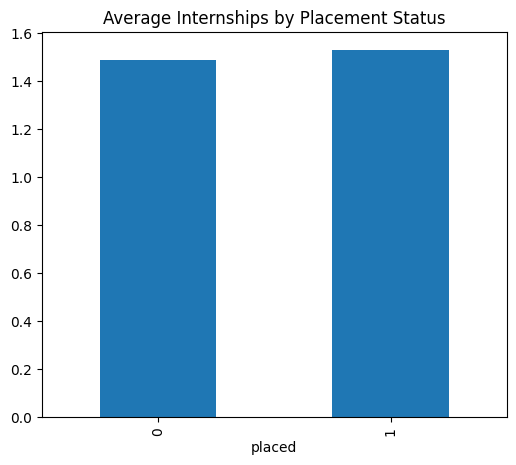

In [11]:
internship.plot(kind="bar", figsize=(6,5))
plt.title("Average Internships by Placement Status")
plt.show()

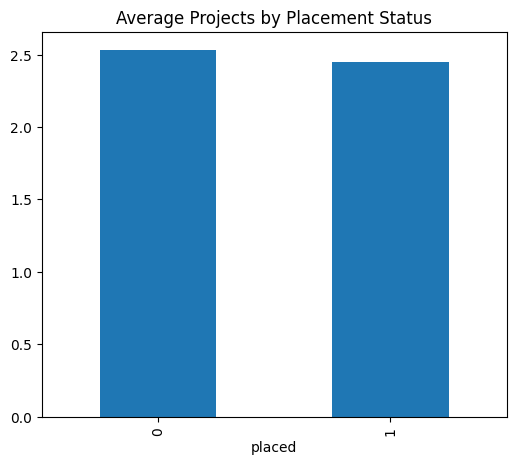

In [12]:
#Do projects improve placement?
projects = placement_df.groupby("placed")["projects"].mean()
projects.plot(kind="bar", figsize=(6,5))
plt.title("Average Projects by Placement Status")
plt.show()

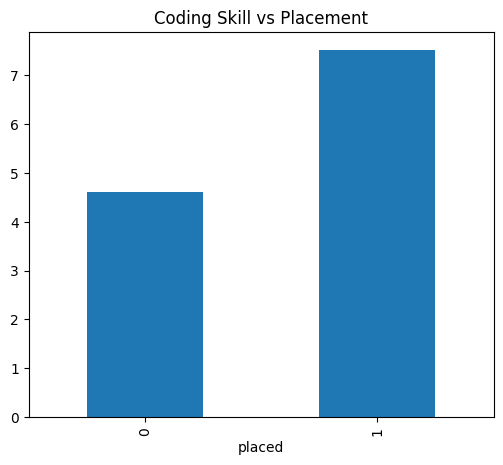

In [13]:
# Does Coding Skill Matter?
coding = placement_df.groupby("placed")["coding_skills"].mean()
coding.plot(kind="bar", figsize=(6,5))
plt.title("Coding Skill vs Placement")
plt.show()

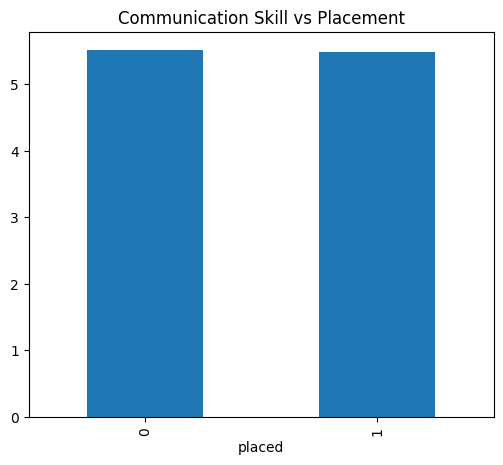

In [14]:
# Communication Skill
communication = placement_df.groupby("placed")["communication_skills"].mean()

communication.plot(kind="bar", figsize=(6,5))

plt.title("Communication Skill vs Placement")

plt.show()

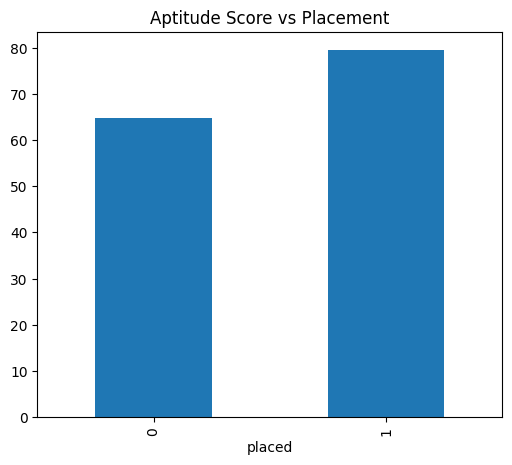

In [15]:
aptitude = placement_df.groupby("placed")["aptitude_score"].mean()

aptitude.plot(kind="bar", figsize=(6,5))

plt.title("Aptitude Score vs Placement")

plt.show()

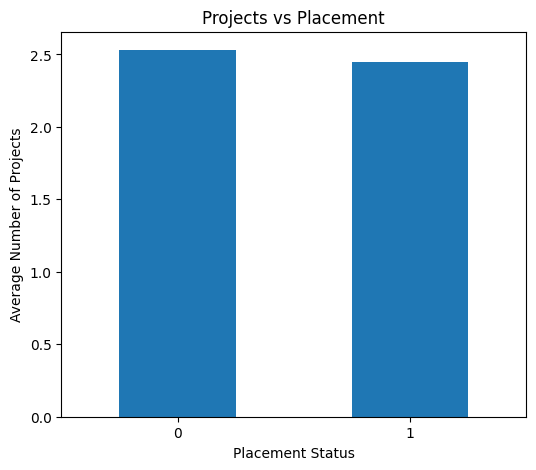

In [17]:
projects = placement_df.groupby("placed")["projects"].mean()

projects.plot(kind="bar", figsize=(6, 5))

plt.title("Projects vs Placement")
plt.xlabel("Placement Status")
plt.ylabel("Average Number of Projects")
plt.xticks(rotation=0)

plt.show()

In [18]:
correlation = placement_df.corr(numeric_only=True)

correlation

,student_id,age,cgpa,backlogs,internships,certifications,coding_skills,communication_skills,aptitude_score,projects,placed,package_lpa
student_id,1.000000,-0.006390,-0.001546,-0.009182,0.004966,0.000762,-0.011399,0.005799,0.005672,-0.003320,0.002590,0.005253
age,-0.006390,1.000000,-0.004947,0.002349,-0.001243,0.009610,-0.005732,-0.004604,0.005833,-0.005875,-0.006673,0.000314
cgpa,-0.001546,-0.004947,1.000000,0.003128,-0.000492,-0.020977,0.005345,-0.009797,-0.007517,0.002082,0.265157,0.240964
backlogs,-0.009182,0.002349,0.003128,1.000000,-0.012760,-0.015461,0.002502,0.002891,-0.018069,-0.011207,-0.000690,-0.000414
internships,0.004966,-0.001243,-0.000492,-0.012760,1.000000,0.005810,0.023873,-0.004764,0.002308,-0.000330,0.016561,0.018460
certifications,0.000762,0.009610,-0.020977,-0.015461,0.005810,1.000000,0.013795,-0.003133,-0.005812,0.020117,0.006796,0.006568
coding_skills,-0.011399,-0.005732,0.005345,0.002502,0.023873,0.013795,1.000000,0.015142,-0.000766,-0.018047,0.462618,0.415762
communication_skills,0.005799,-0.004604,-0.009797,0.002891,-0.004764,-0.003133,0.015142,1.000000,-0.004600,-0.000578,-0.005526,-0.006915
aptitude_score,0.005672,0.005833,-0.007517,-0.018069,0.002308,-0.005812,-0.000766,-0.004600,1.000000,-0.019943,0.390068,0.355406
projects,-0.003320,-0.005875,0.002082,-0.011207,-0.000330,0.020117,-0.018047,-0.000578,-0.019943,1.000000,-0.022528,-0.019110


In [19]:
correlation.to_csv(r"C:\Users\rohit\Documents\CareerInsight AI Student Placement Prediction & Analytics Platform\reports\correlation_matrix.csv")